# Lab Instructions

Create 3 visualizations from a spatial and time-series dataset of your choice.  Describe your dataset including where it came from and the features it contains.  Each visualization should be accompanied by at least 1 - 2 sentences explaining how the features do (or do not!) change over time and througout space.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("city_day.csv")

In [2]:
df.head(20)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


# Dataset Description

## What is this dataset?

This dataset contains **air quality measurements** collected from monitoring stations
across **26 major cities in India**. The data was made publicly available by the
**Central Pollution Control Board (CPCB)**, which is an official agency of the
Government of India (https://cpcb.nic.in/).

## Where did it come from?

The data comes directly from government air quality monitoring stations placed in
cities all over India. These stations automatically record pollution levels and
upload them to a central system. The dataset was compiled and shared publicly on
Kaggle by researcher Rohan Rao.

## What does each row represent?

Each row is one **day of air quality readings for one city**. For example, one row
might represent Delhi on January 1st, 2015, and another row represents Mumbai on
the same day.

## What columns does it have?

| Column | What it means |
|---|---|
| `City` | The name of the city where the reading was taken |
| `Date` | The date of the reading (daily level) |
| `PM2.5` | Tiny particles in the air smaller than 2.5 micrometers — very harmful to lungs |
| `PM10` | Slightly larger particles — also harmful when inhaled |
| `NO` | Nitric oxide — a gas released mainly by vehicles and industries |
| `NO2` | Nitrogen dioxide — causes breathing problems and smog |
| `NOx` | Combined measure of NO and NO2 |
| `NH3` | Ammonia — mainly from agriculture and waste |
| `CO` | Carbon monoxide — a colorless, odorless toxic gas from burning fuel |
| `SO2` | Sulfur dioxide — comes from burning coal and causes acid rain |
| `O3` | Ozone — at ground level it is a harmful pollutant (different from the ozone layer) |
| `Benzene` | A toxic chemical found in vehicle exhaust and industrial emissions |
| `Toluene` | Another industrial chemical pollutant |
| `Xylene` | Another chemical found in paints, fuels, and factories |
| `AQI` | Air Quality Index — a single number summarizing overall air quality |
| `AQI_Bucket` | A category label for the AQI (e.g., Good, Moderate, Poor, Hazardous) |

## Which cities are included?

The dataset covers **26 cities** spread across India:

Ahmedabad, Aizawl, Amaravati, Amritsar, Bengaluru, Bhopal, Brajrajnagar,
Chandigarh, Chennai, Coimbatore, Delhi, Ernakulam, Gurugram, Guwahati,
Hyderabad, Jaipur, Jorapokhar, Kochi, Kolkata, Lucknow, Mumbai, Patna,
Shillong, Talcher, Thiruvananthapuram, and Visakhapatnam.

## What is the AQI?

The **Air Quality Index (AQI)** is a number that summarizes how clean or polluted
the air is on a given day. A low AQI means the air is clean and safe. A high AQI
means the air is polluted and can be harmful — especially for children, the elderly,
and people with breathing conditions. The AQI is calculated by combining multiple
pollutant readings into one score.

## Important notes about the data

- Many rows have **missing values (NaN)** — not every pollutant was measured in
  every city on every day. This is normal for real-world monitoring data.
- The dataset starts from around **2015** and covers several years.
- It is a **spatial and time-series dataset** because it records measurements
  across different locations (cities) over time (daily dates).

## Data Cleaning

Rows where the `AQI` column was empty (NaN) were removed from the dataset,
since AQI is the main variable of interest across all three visualizations.
This ensures cleaner and more reliable plots without gaps or errors.

In [4]:
# Convert Date column

df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M')

In [5]:
# Drop rows where AQI is missing
df = df.dropna(subset=['AQI'])

## Line Chart (AQI over Time for Multiple Cities)

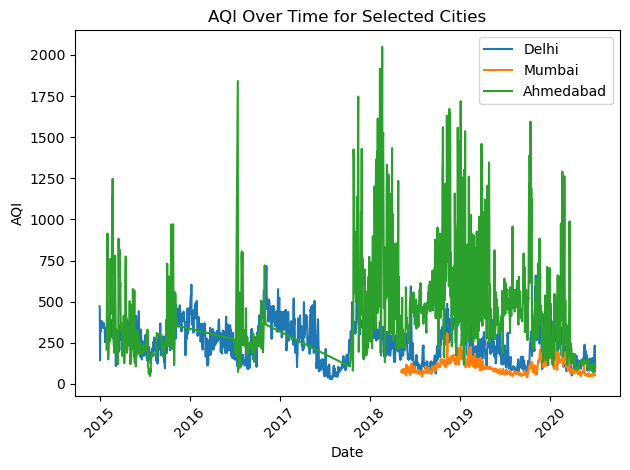

In [6]:
# Select a few cities - for less clutter
cities = ['Delhi', 'Mumbai', 'Ahmedabad']
df_line = df[df['City'].isin(cities)]

plt.figure()
for city in cities:
    city_data = df_line[df_line['City'] == city]
    plt.plot(city_data['Date'], city_data['AQI'], label=city)

plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("AQI Over Time for Selected Cities")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 1: AQI Over Time for Selected Cities

Delhi and Ahmedabad consistently show high AQI levels throughout the entire period
from 2015 to 2020, with Ahmedabad reaching extreme spikes above 2000 on several
occasions. Mumbai, by contrast, maintains much lower and more stable AQI values,
suggesting that air quality varies significantly across space (city location) and
also fluctuates over time — with no clear sign of improvement across the years studied.

## Bar Chart (Average AQI by City)

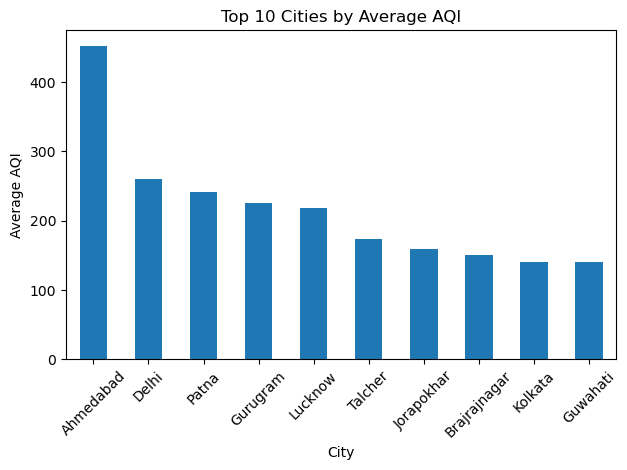

In [7]:
# Compute average AQI per city
avg_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

# Take top 10 polluted cities (cleaner visualization)
top_cities = avg_aqi.head(10)

plt.figure()
top_cities.plot(kind='bar')

plt.xlabel("City")
plt.ylabel("Average AQI")
plt.title("Top 10 Cities by Average AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Visualization 2: Top 10 Cities by Average AQI

Ahmedabad stands out as the most polluted city by far, with an average AQI nearly
double that of Delhi, which ranks second. This spatial comparison shows that air
quality is not uniform across India, northern and western cities like Ahmedabad,
Delhi, Patna, and Gurugram tend to have much worse air quality on average than
cities in the south or northeast.

## Heatmap (City vs Time)

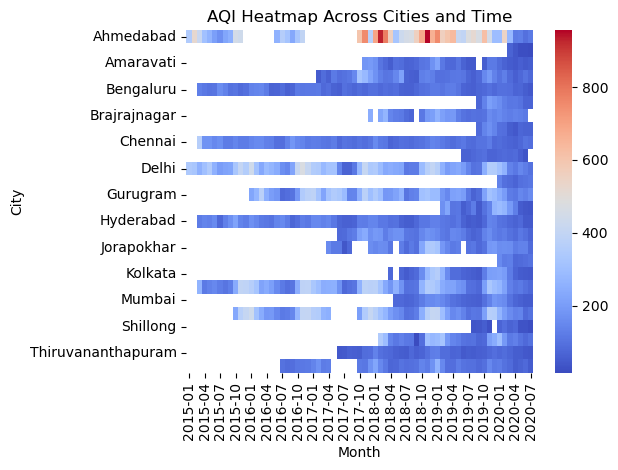

In [8]:
# Create Month column (better than daily → less clutter)
df['Month'] = df['Date'].dt.to_period('M')

# Pivot table
heatmap_data = df.pivot_table(
    values='AQI',
    index='City',
    columns='Month',
    aggfunc='mean'
)

plt.figure()
sns.heatmap(heatmap_data, cmap='coolwarm')

plt.title("AQI Heatmap Across Cities and Time")
plt.xlabel("Month")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### Visualization 3: AQI Heatmap Across Cities and Time

The heatmap combines both time and space in a single view, with each row being a
city and each column being a month from 2015 to 2020. Ahmedabad shows the most
intense red and orange patches, especially around 2018, confirming it has the
highest pollution spikes, while most southern cities like Chennai, Hyderabad, and
Thiruvananthapuram remain in cooler blue tones throughout, indicating consistently
lower AQI levels across all years.